✅ Accuracy: 0.9094455393242447

Confusion Matrix:
 [[22751  2323]
 [ 2134 22011]]

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.91      0.91     25074
           1       0.90      0.91      0.91     24145

    accuracy                           0.91     49219
   macro avg       0.91      0.91      0.91     49219
weighted avg       0.91      0.91      0.91     49219



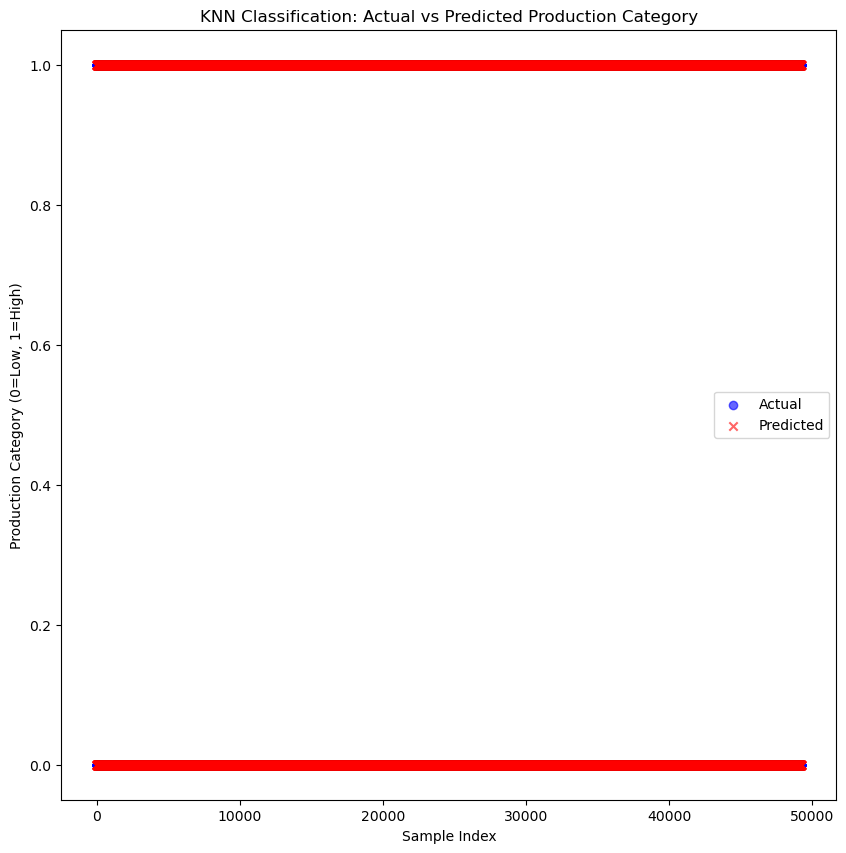

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# -----------------------------
# 1. Load dataset
# -----------------------------
df = pd.read_csv(r"C:\Users\poova\Machine Learning\crop_production.csv")

# -----------------------------
# 2. Features and target
# -----------------------------
X = df[['Crop', 'Area']]

# Encode categorical 'Crop' into numeric (One-Hot Encoding)
X = pd.get_dummies(X, columns=['Crop'], drop_first=True)

# Convert Production into binary categories (High vs Low)
threshold = df['Production'].median()
y = (df['Production'] > threshold).astype(int)   # 1 = High, 0 = Low

# -----------------------------
# 3. Train-test split
# -----------------------------
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# 4. Train KNN Classifier
# -----------------------------
knn = KNeighborsClassifier(n_neighbors=5)  # you can tune n_neighbors
knn.fit(x_train, y_train)

# -----------------------------
# 5. Predictions & Accuracy
# -----------------------------
y_pred = knn.predict(x_test)

print("✅ Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# -----------------------------
# 6. Visualization
# -----------------------------
plt.figure(figsize=(10,10))
plt.scatter(range(len(y_test)), y_test, color='blue', label='Actual', alpha=0.6)
plt.scatter(range(len(y_pred)), y_pred, color='red', marker='x', label='Predicted', alpha=0.6)
plt.title("KNN Classification: Actual vs Predicted Production Category")
plt.xlabel("Sample Index")
plt.ylabel("Production Category (0=Low, 1=High)")
plt.legend()
plt.show()


C:\Users\poova\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


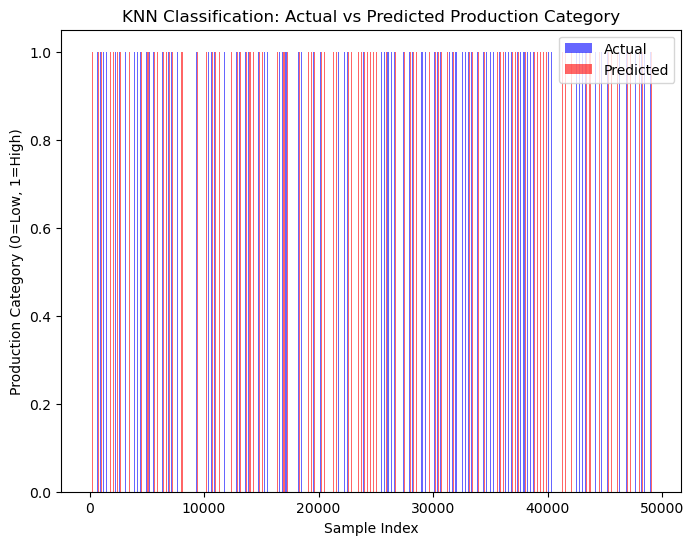

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Sample indices
indices = np.arange(len(y_test))

plt.figure(figsize=(8,6))
width = 0.35  # bar width

# Actual values
plt.bar(indices - width/2, y_test, width, color='blue', alpha=0.6, label='Actual')

# Predicted values
plt.bar(indices + width/2, y_pred, width, color='red', alpha=0.6, label='Predicted')

plt.title("KNN Classification: Actual vs Predicted Production Category")
plt.xlabel("Sample Index")
plt.ylabel("Production Category (0=Low, 1=High)")
plt.legend()
plt.show()
